In [94]:
%load_ext autoreload
%autoreload 2

import featuregraph as fg

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [95]:
df.columns.tolist()

['time',
 'respiration',
 'ecg_ii',
 'ecg_v',
 'ecg_avr',
 'ppg',
 'subject',
 'respiration_smooth',
 'respiration_change',
 'respiration_smooth_valid',
 'respiration_rising',
 'respiration_falling',
 'respiration_inactive',
 'enter_respiration_rising',
 'exit_respiration_rising',
 'exit_respiration_rising_id',
 'respiration_minus_smoothing']

In [96]:
subject_id = 33
sampling_rate_hz = 125
smooth_window = 100
eps = 1e-12

df = fg.datasets.bidmc(subject=subject_id).copy()

# Construct the respiratory envelope.
df['respiration_smooth'] = (
    df['respiration']
    .rolling(smooth_window, min_periods=smooth_window)
    .max()
    .rolling(smooth_window, min_periods=smooth_window)
    .mean()
    .shift(-smooth_window)
)

# Preserve the signed change.
df['respiration_change'] = (
    df['respiration_smooth'].diff()
)

# A sample is valid for state assignment only when both the envelope
# and its preceding difference are defined.
df['respiration_smooth_valid'] = (
    df['respiration_smooth'].notna()
    & df['respiration_change'].notna()
)

valid = df['respiration_smooth_valid']

# Mutually exclusive directional states.
df['respiration_rising'] = (
    valid
    & df['respiration_change'].gt(eps)
)

df['respiration_falling'] = (
    valid
    & df['respiration_change'].lt(-eps)
)

df['respiration_inactive'] = (
    valid
    & df['respiration_change'].abs().le(eps)
)

# Initialize events as False everywhere, including invalid edge samples.
df['enter_respiration_rising'] = False
df['exit_respiration_rising'] = False

# Calculate events only within the valid constructed interval.
df.loc[valid, 'enter_respiration_rising'] = (
    df.loc[valid, 'respiration_rising']
    .astype(int)
    .diff()
    .eq(1)
)

df.loc[valid, 'exit_respiration_rising'] = (
    df.loc[valid, 'respiration_rising']
    .astype(int)
    .diff()
    .eq(-1)
)

# Assign identity only after the final event columns have been constructed.
df['exit_respiration_rising_id'] = (
    df['exit_respiration_rising']
    .astype(int)
    .cumsum()
)

df['respiration_minus_smoothing'] = df['respiration'] - df['respiration_smooth']

# Validate state exclusivity and completeness.
state_columns = [
    'respiration_rising',
    'respiration_falling',
    'respiration_inactive',
]

state_count = df[state_columns].sum(axis=1)

assert state_count[valid].eq(1).all()

In [97]:
summarydf = df.groupby('exit_respiration_rising_id').agg(
    respiration_rising_samples=('respiration_rising', 'sum'),
    respiration_falling_samples=('respiration_falling', 'sum'),
    respiration_inactive_samples=('respiration_inactive', 'sum'),
    enter_rising_count=('enter_respiration_rising', 'sum'),
    exit_rising_count=('exit_respiration_rising', 'sum'),
    start_index=('time', 'first'),
    end_index=('time', 'last'),
)

In [98]:
summarydf

,respiration_rising_samples,respiration_falling_samples,respiration_inactive_samples,enter_rising_count,exit_rising_count,start_index,end_index
exit_respiration_rising_id,,,,,,,
0,161,183,17,1,0,0.000,3.672
1,106,35,3,1,1,3.680,4.824
2,143,209,48,1,1,4.832,8.024
3,109,29,0,1,1,8.032,9.128
4,145,169,76,1,1,9.136,12.248
...,...,...,...,...,...,...,...
165,112,62,6,1,1,467.380,468.810
166,209,291,54,1,1,468.820,473.240
167,116,13,1,1,1,473.250,474.280


(<Figure size 1600x1320 with 6 Axes>,
 array([<Axes: ylabel='respiration'>, <Axes: ylabel='respiration_smooth'>,
        <Axes: ylabel='respiration_minus_smoothing'>,
        <Axes: ylabel='ecg_ii'>, <Axes: ylabel='ecg_v'>,
        <Axes: xlabel='Time', ylabel='exit_respiration_rising'>],
       dtype=object))

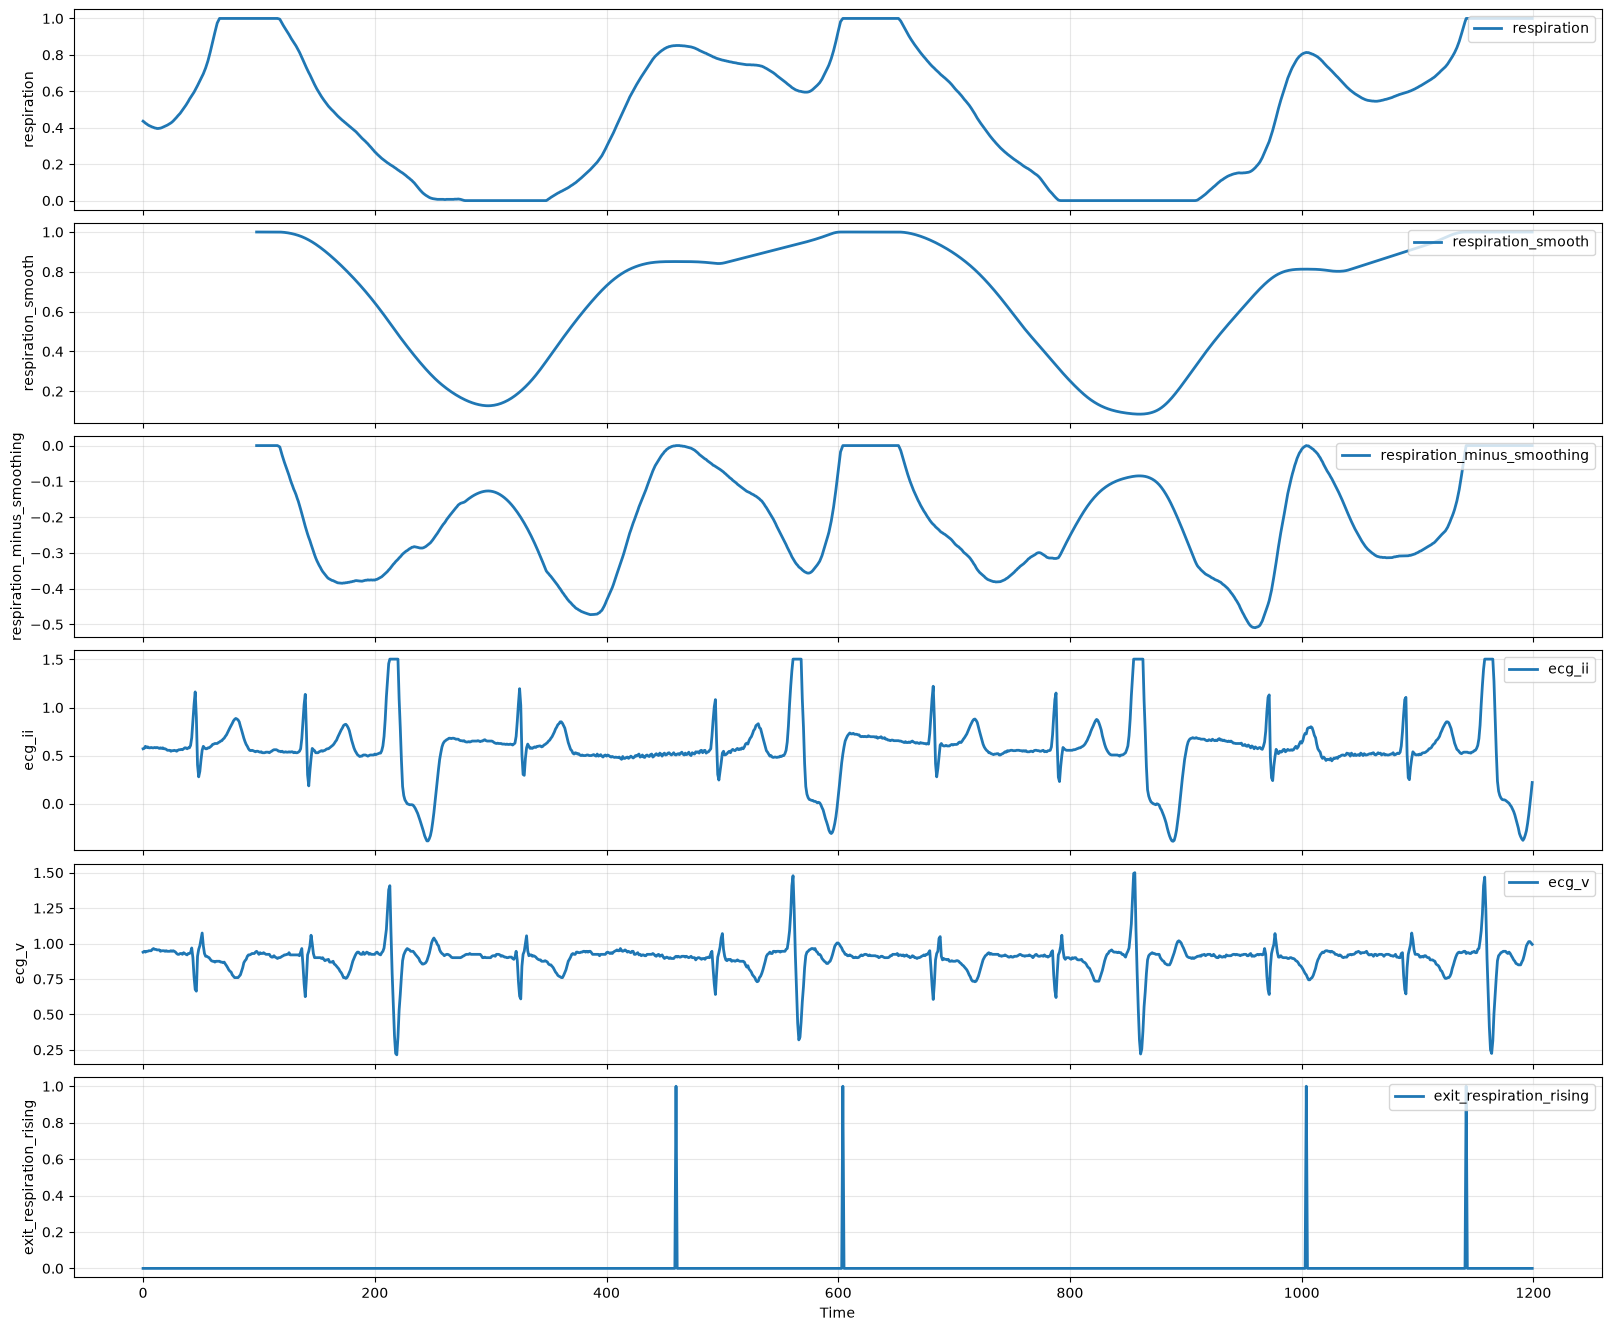

In [99]:
fg.plot(df[:1200], [['respiration'],
                              ['respiration_smooth'],
                              ['respiration_minus_smoothing'],
                              ['ecg_ii'],
                              ['ecg_v'],
                            #   ['respiration_falling'],
                            #   ['respiration_inactive'],
                            #   ['enter_respiration_rising'],
                              ['exit_respiration_rising'],
                            #   ['exit_respiration_rising_id']
                             ]
)